# **集成学习**

**原理**: 通过构建并结合多个 **“基学习器” (Base Learners)** 来完成学习任务，从而获得比单一学习器更好的预测性能。

**单一模型往往存在两个主要问题**：

- 偏差 (Bias) 高： 模型太简单，没学会数据的规律（欠拟合）。

- 方差 (Variance) 高： 模型太复杂，死记硬背了训练数据，换个数据就不行了（过拟合）。

集成学习通过组合多个模型，试图同时解决或缓解这两个问题。根据组合方式的不同，集成学习主要分为三大流派：**Bagging**、**Boosting** 和 **Stacking**。

## **Bagging(Bootstrap Aggregating，引导聚合)**

### **原理**

**核心思想**: 通过构建多个**独立且同质** 的基学习器,大家独立并行地学习,最后投票决定结果.

**构建流程**:

1. **Bootstrap（自助采样）**:从原始训练集中**有放回地**随机抽取N个样本，生成多个不同的子数据集。这个过程重复多次（比如100次），得到多个略有差异的数据子集。

2. **训练**: 用同一个基础学习算法（如决策树），在每个数据子集上独立训练一个模型。

3. **聚合结果**：

- 分类问题： 少数服从多数（投票）。

- 回归问题： 计算平均值。

**特点**: 主要目标是降低方差，特别适用于那些本身复杂度高、容易过拟合的模型（如深度决策树）。

**典型代表**： 随机森林。它是Bagging的扩展，在构建每棵决策树时，不仅对样本进行随机采样，还会随机选取一部分特征进行节点分裂。这种“双重随机性”进一步增强了模型的多样性，防止模型之间过于相似，效果通常比普通Bagging更好。

### **随机森林(Random Forest)**

#### **bootstrap(随机)采样原理**

在进入随机森林之前，先深入理解Bagging的核心——Bootstrap采样：

对于一个包含N个样本的训练集D，进行Bootstrap采样：

- 每次有放回地随机抽取1个样本

- 重复N次，形成一个包含N个样本的新训练集D_t

**数学推导：**

一个样本在单次抽取中被抽中的概率：$\frac{1}{N}$

​
一个样本在单次抽取中未被抽中的概率：$1-\frac{1}{N}$

​
经过N次独立抽取，一个样本从未被抽中的概率：$P(从未被抽中)=\left(1-\frac{1}{N}\right)^N$

当$N→∞$时: $\displaystyle \lim_{N \to \infty}{\left(1-\frac{1}{N}\right)^N} = e^{-1} \approx 0.368$

**重要结论**：在Bootstrap采样中，大约有**36.8%**的原始样本不会出现在采样集中，这些样本称为**袋外样本(Out-Of-Bag, OOB)**。


#### **原理**

**随机森林** 其实有两部分组成,即 **随机**和**森林**

1. **森林**: 算法内部有很多棵决策树,每棵树都是一个基学习器.


2. **随机**:这便是灵魂所在,如果训练集中有比较明显的特征,那么那么几乎所有的树都会在根节点或靠近根节点的位置使用这个特征进行分裂,导致每棵树的结构都会高度的相似.为了让每棵树都有差异性,随机森林引入了两个层面的随机性:
    1. **样本随机采样**: 每次从训练集中随机采样,构建一个新的数据集(bootstrap 采样,同bagging).
    2. **特征随机采样**: 在每个节点分裂时，不是从所有d个特征中选择最佳分裂特征，而是：
        - 先随机选取$m$个特征($m<=d$)
        - 从这$m$个特征中选择最佳分裂特征


3. **随机森林的两大“特异功能”**
   
    除了预测准确，随机森林还有两个非常有用的特性，让它在工业界备受青睐：

    **A. OOB (Out-of-Bag) 评估 —— 自带验证集**

    在 Bootstrap 抽样时，大约有 36.8% 的数据不会被抽中。

    - 这意味着，我们不需要专门切分“验证集”来测试模型好坏。

    - 我们可以直接用这 36.8% 的 OOB 数据来测试那棵树的性能。

    - 结论： 随机森林自带验证机制，省去了交叉验证的时间。

    **B. 特征重要性 (Feature Importance)** 

    随机森林可以告诉你：在这个任务中，哪个特征最重要？

    - **原理：** 如果我们把某个特征的数据打乱（加入噪声），导致树的预测错误率飙升，说明这个特征很重要；如果打乱后错误率没变化，说明这个特征可有可无。

    - **用途：** 这在数据分析和解释模型时非常有用（例如：银行想知道拒绝贷款时，是“信用记录”重要还是“收入水平”重要）。

#### **构建过程**

假设我们有一个数据集，包含 $N$ 个样本和 $M$ 个特征。随机森林的构建过程如下：

**第一步：Bootstrap 抽样（样本随机）**

我们不把所有数据都给每一棵树。对于第 $k$ 棵树：

- 我们从原始数据集中，有放回地随机抽取 $n$ 个样本。
- 结果： 有的样本可能被抽中多次，有的样本可能一次都没被抽中（Out-of-Bag / OOB (袋外样本)）。
- 目的： 保证每棵树看到的训练数据略有不同。

**第二步：特征随机选择（特征随机）**

在决策树构建过程中，通常在每个节点分裂时，会遍历所有$ M$ 个特征来找最好的分裂点。

- 但在随机森林中，**绝不遍历所有特征**。

- 它会随机选择一小部分特征（通常是 $\sqrt{M}$或 $\log_2{M}$ 个）。

- 仅在这个子集中寻找最好的分裂特征。

- 目的： 即使某个特征非常强（比如“收入”对预测“消费”很关键），我们也不希望每棵树都第一时间用它。我们要强迫一些树去关注其他次要特征，这样才能从不同角度理解数据，防止过拟合。

**第三步：构建决策树**

按照上述规则，让每棵决策树**充分生长**（通常不剪枝，或者剪枝很少）。这意味着每棵树虽然方差大（容易过拟合自己的子数据），但偏差小（学得深）。

**第四步：集成投票**

当新的数据来了，我们把它输入给森林中的每一棵树：

**分类问题**： 就像投票选举。如果是二分类，100棵树里有60棵说是A，40棵说是B，那最终结果就是 A。

**回归问题**： 计算所有树预测值的平均值。

#### **优缺点**

|优点|缺点|
|--|--|
|**准确率高：** 在大多数结构化数据上表现极佳。|**模型庞大：** 包含几百棵树，模型文件大，占用内存多。|
|**抗过拟合：** “双重随机”机制让它很难过拟合。|**预测慢：** 预测时需要几百棵树都跑一遍，比单棵树慢得多（不适合毫秒级响应的实时系统）。|
|**傻瓜式调参：** 很多时候默认参数就能跑出很好的结果。|**黑盒：** 很难解释具体的决策路径（不像单棵决策树那样可以画出清晰的流程图）。|
|**处理高维数据：** 不需要做复杂的特征筛选。||


#### **代码演示**

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 准备数据
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. 构建模型
# n_estimators=100 表示种100棵树
# max_features='sqrt' 表示每次分裂只看根号下总特征数个特征
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

# 3. 训练 (并行训练，速度快)
rf.fit(X_train, y_train)

# 4. 预测
y_pred = rf.predict(X_test)

# 5. 查看结果
print(f"准确率: {accuracy_score(y_test, y_pred)}")

# 6. 查看特征重要性
print("特征重要性:", rf.feature_importances_)

准确率: 0.8888888888888888
特征重要性: [0.11106946 0.01736048 0.48712805 0.38444201]


## **Boosting(提升法)**

### **原理**


多个弱学习器**串行**执行, 每个弱学习器都在尝试改进**前一个**弱学习器的**错误**, 最终得到一个强学习器.

有两种 Boosting 算法：AdaBoost 和 GBDT。

**举个例子**: 

第一轮： 先派出一个“弱学生”（模型 A）去考试，考完后看看哪几题做错了。

第二轮： 派出第二个“弱学生”（模型 B）。注意，模型 B 的任务不是重考一遍，而是专门去攻克模型 A 做错的那些题。

第三轮： 派出模型 C，专门去攻克 A 和 B 都没搞定的难题。

最后： 把 A、B、C... 的答案加起来（加权），形成最终答案。



**关键点**：

- **串行训练**： 模型之间有依赖关系，后一个模型依赖前一个模型的结果。

- **关注错误**： 每一轮训练的目标，都是为了减小上一轮的误差。

- **弱学习器**： Boosting 通常使用很简单的模型（比如深度只有 3-5 层的决策树）作为基学习器。因为它相信通过不断的叠加，简单的模型也能变强。

### **AdaBoost(Adaptive Boosting 自适应提升)**

#### **原理**

前一个基本分类器分错的样本，会使其在后一个基本分类器中得到加强(**加权**)，加权后的全体成员组成了分类器。

AdaBoost 通常使用**决策树桩** (Decision Stump) 作为基学习器。

- 注：决策树桩就是只有一层的决策树，它像一棵很简单的树，一次只能切一刀，非常简单，非常弱。

#### **构建流程**

**第一步：初始化权重**

一开始，所有 $N$ 个训练样本的权重是平等的，都是 $1/N$。大家生而平等。

**第二步：迭代训练（假设循环 T 轮）**

对于每一轮 $t$ (from 1 to T):

1. **训练模型：** 使用当前权重的样本数据，训练一个弱分类器 $h_t$（比如一个树桩）。
2. **计算错误率 ($\epsilon_t$)**： 看看这个模型把多少权重的样本分错了。
3. **计算模型话语权 ($\alpha_t$)**： 这一点至关重要！
   - 如果错误率 $\epsilon_t$ 很低，说明这个模型很强，给它很高的投票权重 $\alpha_t$。
   - 如果错误率 $\epsilon_t$ 很高（接近 0.5），说明这个模型在瞎猜，给它的权重就很低。
   - 公式直觉： $$\alpha_t = \frac{1}{2} \ln(\frac{1-\epsilon_t}{\epsilon_t})$$
4. 更新样本权重： 这是最关键的一步（Adaptive 的体现）。
   - 对于分错的样本： 增加它们的权重。下一轮训练时，新的模型会优先“照顾”这些样本，因为分错它们的代价变大了。
   - 对于分对的样本： 降低它们的权重。既然已经学会了，下一轮就不用花太多精力在它们身上。


**第三步：强力结合训练完** 

T 个模型后，把它们组合起来。最终预测结果 = $sign(\alpha_1 \cdot h_1 + \alpha_2 \cdot h_2 + ... + \alpha_T \cdot h_T)$(翻译：所有弱分类器的结果，乘以它们各自的话语权，加起来看是正还是负。)

**一个具体的数学直觉**

AdaBoost 最精妙的地方在于它如何调整样本权重。

假设第 $i$ 个样本被预测错了，它的权重更新公式大概长这样：$$w_{new} = w_{old} \cdot e^{\alpha}$$假设第 $i$ 个样本被预测对了，它的权重更新公式大概长这样：$$w_{new} = w_{old} \cdot e^{-\alpha}$$因为 $\alpha$ 是正数（前提是模型准确率 > 50%），所以 $e^{\alpha} > 1$，错题权重变大。$e^{-\alpha} < 1$，对题权重变小。通过这种指数级的调整，经过几轮后，那些一直被分错的“顽固样本”权重会变得巨大，迫使算法必须要把它们分开。

#### **优缺点**

**优点**

- **精度高**： 它可以把很多个很弱的分类器组合成一个超强的分类器。

- **不容易过拟合**： 这是一个比较反直觉的结论，但在很多情况下，AdaBoost 即使训练很多轮，泛化能力依然很好（当然到了后期还是会过拟合的）。

- **简单灵活**： 它可以结合各种算法（不只是树），只要是弱学习器就行。



**缺点**

- **对异常值（Outliers）极度敏感！**

    - 为什么？ 因为 AdaBoost 的逻辑是“你越错，我越关注你”。

    - 如果是正常的“难样本”还好。但如果数据里有一个错误标注的噪音（比如把一张猫的图强行标成狗），AdaBoost 会拼命地加大这个样本的权重，发疯一样想把它分对，最后导致模型跑偏，为了这一个噪音破坏了整体规则。

- **无法并行**： 必须等前一个模型练完，算出错误率，更新完权重，才能练下一个。

#### **代码演示**

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 造一点数据
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. 设定基学习器：一个深度只有1的决策树（树桩），非常弱
weak_learner = DecisionTreeClassifier(max_depth=1)

# 3. 构建 AdaBoost
# n_estimators=50 : 迭代50轮
# algorithm='SAMME.R' : 一种优化的AdaBoost算法
ada = AdaBoostClassifier(estimator=weak_learner, n_estimators=50, learning_rate=1.0, random_state=42)

# 4. 训练
ada.fit(X_train, y_train)

# 5. 预测
y_pred = ada.predict(X_test)

print(f"AdaBoost 准确率: {accuracy_score(y_test, y_pred)}")

# 对比：如果我们只用那个单层的弱鸡决策树，效果如何？
weak_learner.fit(X_train, y_train)
print(f"单层决策树准确率: {weak_learner.score(X_test, y_test)}")

AdaBoost 准确率: 0.87
单层决策树准确率: 0.85


### **GBDT(Gradient Boosting Decision Tree 梯度提升决策树)**

#### **基本原理**

**残差 = 真实值 - 预测值**

**举个生动的例子：猜年龄**

假设我们要预测这名用户的年龄，他的真实年龄是 30岁。

**第一轮（第一棵树）：**
- **目标**： 预测真实年龄 30。
- **训练**： 树 A 看了看特征，给出的预测值是 20岁。
- **残差**： $30 - 20 = 10$。
- 意味着： 我们还差 10 岁没预测对。
  
**第二轮（第二棵树）**：
- **关键点来了：** 这棵树的目标不再是预测 30，而是去预测那个残差 10。
- **训练：** 树 B 看了看特征，它的预测任务是填补这 10 岁的空缺。假设它预测出了 6岁。
- **新残差：** $10 - 6 = 4$。意味着： 现在还差 4 岁。

**第三轮（第三棵树）**：
- **目标：** 去预测剩下的残差 4。
- **训练：** 树 C 很准，直接预测出了 4岁。
- **新残差：** $4 - 4 = 0$。意味着： 我们已经预测对了 4 岁。
- **最终结果（集成）**：我们将所有树的预测值加起来：$$预测值 = 树A(20) + 树B(6) + 树C(4) = 30$$
  
**这就是 GBDT 的核心思想：每一棵树都是建立在之前所有树的“错误”（残差）之上的，每一棵树都在一点点修补偏差。**


#### **为什么叫'梯度'**

**损失函数(MSE)**: $$Loss = \frac{1}{2}(y - \hat y)^2$$

如果我们对这个 Loss 求导（求梯度）：$$\frac{\partial Loss}{\partial \hat{y}} = -(y - \hat{y})$$

你会发现：**负梯度 (Negative Gradient)** 恰好就是 $y - \hat{y}$，也就是**残差**！


**结论：**

- 当我们使用“均方误差”作为损失函数时，**拟合残差 = 拟合负梯度**。它们是一回事。

- 如果我们换一个损失函数（比如处理分类问题的 LogLoss，或者处理异常值的 Huber Loss），残差和梯度就不完全一样了。

- GBDT 的厉害之处在于： 无论你用什么复杂的损失函数，我这一轮树的目标，永远是去**拟合损失函数的负梯度（下降最快的方向）**。因为在数学上，负梯度方向就是让 Loss 减小最快的方向。

**GBDT 实际上是一个更广义的算法，拟合残差只是它的一种特例**

#### **特点**

1. **只能用回归树 (Regression Tree)**：
   - 即使是做**分类任务**（比如预测通过/不通过），GBDT 内部用的也是回归树！
   - 为什么？ 因为它要拟合的是“残差”（一个数值），比如残差是 0.5 或 -1.2。显然，只能做加减法的回归树才能完成“累加”的任务。分类树（输出类别 A、B）是没法做加减法的。
2. **串行生成 (Serial)**：
   - 必须等第一棵树练好了，算出残差，才能练第二棵。所以它很难并行训练（速度慢是它的硬伤）。
3. **Shrinkage (缩减/学习率)**：
   - 为了防止过拟合，GBDT 不会完全信任每一棵树。
   - 公式： $最终结果 = base + 0.1 \times 树1 + 0.1 \times 树2 + 0.1 \times 树3 ...$
   - 那个 0.1 就是学习率 (Learning Rate)。这意味着我们不希望一棵树就把残差全补完，而是要“小步快跑”，每棵树只补一点点，多用几棵树。这样模型的泛化能力更强。

|**特性**|**AdaBoost**|**GBDT**|
|--|--|--|
|**核心策略**|**加权**：给做错的样本加权重。|**残差**：去拟合之前预测的误差（梯度）。|
|**解决问题**|分类问题为主。|回归问题为主（分类也能转成回归处理）。|
|**异常值**|**非常敏感**：会被异常值带偏。|**相对鲁棒**：虽然也敏感，但可以通过换 Loss 函数（如 Huber Loss）来忽略异常值。|
|**基学习器**|常用决策树桩（极简树）。|常用 CART 回归树（深度稍深，如 3-6 层）|
|**并行计算**|否（串行）。|否（串行）。|

#### **手写一个 GBDT 模型**

In [3]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# 1. 准备数据：比如预测某人的消费能力
# 特征 X (比如收入), 标签 y (实际消费)
X = np.array([[10], [20], [30], [40], [50]])
y = np.array([5, 7, 9, 11, 13])  # 真实值，其实就是 y = 0.2*x + 3

# ================= 第 1 轮 =================
# 第一棵树直接拟合 y
tree1 = DecisionTreeRegressor(max_depth=2)
tree1.fit(X, y)
pred1 = tree1.predict(X)

# 计算残差 (真实值 - 预测值)
residual1 = y - pred1
print(f"第1轮预测: {pred1}")
print(f"第1轮残差: {residual1}")
# 假设输出: [5. 7. 9. 11. 13.] (其实决策树不可能完美拟合，这里假设它拟合了一部分)
# 实际输出可能是: [ 6.  6.  9. 12. 12.] (举例)
# 对应残差就是: [-1.  1.  0. -1.  1.]

# ================= 第 2 轮 =================
# 关键：第二棵树拟合的是 residual1 (上一轮的残差)
tree2 = DecisionTreeRegressor(max_depth=2)
tree2.fit(X, residual1) # 注意这里 y 变成了 residual1
pred2 = tree2.predict(X)

# ================= 集成预测 =================
# 新的预测值 = 第1棵树的结果 + 第2棵树的结果
final_pred = pred1 + pred2

print("-" * 20)
print(f"第2轮对残差的预测: {pred2}")
print(f"集成后的最终预测: {final_pred}")
print(f"真实值: {y}")

第1轮预测: [ 5.  7.  9. 12. 12.]
第1轮残差: [ 0.  0.  0. -1.  1.]
--------------------
第2轮对残差的预测: [ 0.  0.  0. -1.  1.]
集成后的最终预测: [ 5.  7.  9. 11. 13.]
真实值: [ 5  7  9 11 13]


### **XGBoost(eXtreme Gradient Boosting )**

GBDT 理论虽好，但在工程实现上有一个大问题：慢！ 而且很容易过拟合。 为了解决这些问题，提出了 XGBoost算法.

XGBoost的目标是: **误差要小,模型要简单**

**大概原理**: XGBoost会判断某个节点是否值得分裂,会计算**当前节点的增益**和**当前节点分裂后的增益**,如果分裂后的增益更大,则该节点就会分裂.

#### **公式推导**




##### **第一步**: **定义目标函数**

XGBoost在GBDT的基础上引入了一个惩罚系数

①$$Obj^{(t)} = \sum_{i=1}^{n} L(y_i, \hat{y}_i^{(t)}) + \sum_{k=1}^{t} \Omega(f_k)$$

②$$\Omega(f_k) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_{j}^2$$

- **Obj**(Objective Function): 目标函数, 用于衡量模型的预测能力.
- **L**(Loss Function): 损失函数,比如均方误差.
- **$\Omega(f_k)$**: 正则项, 用于控制模型的复杂度, 防止过拟合.(惩罚系数)
- **T**: 叶子节点的数量,惩罚树的结构复杂度(叶子越多越复杂).
- **$\gamma$**: 控制叶子数量的惩罚系数.
- **$\lambda$**: 控制权重的惩罚系数.
- **$w_{j}$**: 叶子节点权重的L2模平方 $||w||^2$,第j个叶子节点的权重.惩罚叶子权重的幅度,避免某些叶子权重过大

我们先分析公式①,其中: 

第 $t$ 轮的预测值 = 前 $t-1$ 轮的预测值 + 当前这棵树的预测值：

$$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$$

$\sum_{k=1}^{t} \Omega(f_k)$ 的意思是：从第 1 棵树到第 $t$ 棵树，所有树的复杂度之和。所以到了第 $t$ 轮，前 $t-1$ 轮的值可以看成常数：
$$\text{常数} + \Omega(f_t)$$


把拆解的公式带入原目标函数，我们得到：
$$Obj^{(t)} = \sum_{i=1}^{n} L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t) + \text{常数}$$

**举个例子来理解$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_k(x_i)$公式**

>
>假设我们要预测用户的年龄，他的真实年龄是 30岁。
> 
>**第一轮（第一棵树）：**
> 预测了20
> 残差为10
>  
>**第二轮（第二棵树）**：
>- **关键点来了：** 这棵树的目标不再是预测 30，而是去预测那个残差 10。
>- 预测了6
> - 当前轮的预测值为 = 上一轮的预测值+当前这一轮的预测值:26=20+6
>  
>**第三轮（第三棵树）**：
>- 预测了4
> - 当前轮的预测值为 = 上一轮的预测值+当前这一轮的预测值:30=26+4
>- **最终结果（集成）**：我们将所有树的预测值加起来：$$预测值 = 树A(20) + 树B(6) + 树C(4) = 30$$


##### **第二步: 泰勒展开**


损失函数 $L$ 可能很复杂（比如 LogLoss），不好求导。为了简化计算，我们用**二阶泰勒展开**来近似它。

复习泰勒公式： $f(x + \Delta x) \approx f(x) + f'(x)\Delta x + \frac{1}{2}f''(x)\Delta x^2$

把我们的损失函数套进去：
- $x$ 对应 $\hat{y}_i^{(t-1)}$ (旧预测值)
- $\Delta x$ 对应 $f_t(x_i)$ (新的一棵树，也就是我们要算的增量)

展开后变成：
$$L(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) \approx L(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i)$$

这里定义了两个关键变量（XGBoost 的核心）：
- $g_i$ (一阶导/梯度)： $\frac{\partial L(y_i, \hat{y}^{(t-1)})}{\partial \hat{y}^{(t-1)}}$
- $h_i$ (二阶导/海森)： $\frac{\partial^2 L(y_i, \hat{y}^{(t-1)})}{\partial (\hat{y}^{(t-1)})^2}$


现在目标函数变成了：
$$Obj^{(t)} \approx \sum_{i=1}^{n} [ g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i) ] + \Omega(f_t)$$
- (第一项 $L(y_i, \hat{y}_i^{(t-1)})$ 是上一轮的误差，已知常数，去掉)

##### **第三步: 从'样本'视角切换到'叶子'视角(关键转换)**

现在的公式里，$\sum_{i=1}^{n}$ 是在遍历所有**样本**。但是，我们训练树的时候，样本最终都会落到某个**叶子节点**上。假设树有 $T$ 个叶子，第 $j$ 个叶子里的样本集合是 $I_j$。第 $j$ 个叶子上的所有样本，预测值都是一样的，都是 $w_j$。所以，我们可以把 $\sum_{i=1}^{n}$ (样本求和) 改写成 $\sum_{j=1}^{T}$ (叶子求和)。

所以，我们可以把 $\sum_{i=1}^{n}$ (样本求和) 改写成 $\sum_{j=1}^{T}$ (叶子求和)。
$$Obj^{(t)} = \sum_{j=1}^{T} [ (\sum_{i \in I_j} g_i) w_j + \frac{1}{2} (\sum_{i \in I_j} h_i + \lambda) w_j^2 ] + \gamma T$$

为了书写方便，我们定义：
- $G_j = \sum_{i \in I_j} g_i$ （第 $j$ 个叶子里所有样本的一阶导之和）
- $H_j = \sum_{i \in I_j} h_i$ （第 $j$ 个叶子里所有样本的二阶导之和）

**最终得到的简洁目标函数**：
$$Obj^{(t)} = \sum_{j=1}^{T} [ G_j w_j + \frac{1}{2} (H_j + \lambda) w_j^2 ] + \gamma T$$

##### **第四步:求解一元二次方程**

仔细看上面那个方括号里的式子。对于第 $j$ 个叶子，这不就是一个关于 $w_j$ 的一元二次方程吗？
$$f(w_j) = \frac{1}{2}(H_j + \lambda)w_j^2 + G_j w_j $$

这就是 $ax^2 + bx + c$ 的形式。
- $a = \frac{1}{2}(H_j + \lambda)$
- $b = G_j$



我们要求这个函数的**最小值**。
二次函数 $ax^2+bx+c$ 的**极值点**在对称轴 $x = - \frac{b}{2a}$ 处取得。

所以，最佳的叶子权重 $w_j^*$ 是：
$$w_j^* = - \frac{G_j}{H_j + \lambda}$$

把这个最佳权重代回原方程，算出最小的目标函数值 (**结构分数**)：
$$Obj^* = - \frac{1}{2} \sum_{j=1}^{T} \frac{G_j^2}{H_j + \lambda} + \gamma T$$

这个值可以用来衡量树结构的好坏。**值越小，说明树的结构越好**。

##### **第五步: 计算增益**


$Obj^*$ 就是打分公式。比如你想分裂分一个节点，你就算一下.
- 切分前的分数：$Score_{root}$
- 切分后的分数：$Score_{left} + Score_{right}$

增益: $$Gain= \frac{1}{2} [\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}] - \gamma$$

- $Gain>0$ 说明分裂后损失更小,是一个好的分裂点,会考虑此次分裂.
- $Gain=0$ 说明分裂后损失没有变化,不会考虑此次分裂.
- $Gain<0$ 说明分裂后损失更大,不是一个好的分裂点,不会考虑此次分裂.
  
如果（左子树得分 + 右子树得分 - 不切分的得分） > $\gamma$，说明切分带来的好处超过了增加叶子数量的代价（$\gamma$），那就切！否则就不切。

#### **代码演示**

In [ ]:
# pip install xgboost
# 红酒品质预测
import pandas as pd
from collections  import Counter
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.utils import class_weight
from sklearn.model_selection import StratifiedKFold, GridSearchCV

df = pd.read_csv('./data/winequality-red.csv')
# df.info()
# print(df.head(5))
x = df.iloc[:, :-1]  # 特征,除了最后一列
y = df.iloc[:, -1]  # 标签,只有最后一列
# print("最后一列分布情况:", Counter(y))
# 最后一列分布情况: Counter({5: 681, 6: 638, 7: 199, 4: 53, 8: 18, 3: 10})
# 可以看出,最后一列的分布情况是不均衡的,5和6的数量最多,3和8的数量最少,并且索引是从3到8
# 可以将索引变成从0到5
y = y.map(lambda x: x - 3)
# print("最后一列分布情况:", Counter(y))
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 参考y轴进行抽取,保持测试集和训练集的标签比例一致(数据均衡)
)
# 模型1:不考虑数据均衡问题,直接训练
estimator1 = xgb.XGBClassifier(
    objective='multi:softmax',  # 多分类问题,使用softmax损失函数
    num_class=6,  # 类别数量
    max_depth=5,  # 树的最大深度
    learning_rate=0.1,  # 学习率
    n_estimators=100,  # 树的数量
    random_state=42  # 随机种子
)
estimator1.fit(x_train, y_train)
print("模型1准确率:",estimator1.score(x_test, y_test))
# 模型2:使数据更均衡
sample_weight = class_weight.compute_sample_weight(
    'balanced',
    y=y_train # 参考标签分布平衡权重
)
estimator2 = xgb.XGBClassifier(
    objective='multi:softmax',  # 多分类问题,使用softmax损失函数
    num_class=6,  # 类别数量
    max_depth=5,  # 树的最大深度
    learning_rate=0.1,  # 学习率
    n_estimators=100,  # 树的数量
    random_state=42  # 随机种子
)
estimator2.fit(x_train, y_train, sample_weight=sample_weight)
print("模型2准确率:",estimator2.score(x_test, y_test))

# 模型3: 使用网格搜索和交叉验证
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [50, 100, 200],
}
# 创建分层采样对象

skf = StratifiedKFold(
    n_splits=5, # 分割成5份(5折)
    shuffle=True, # 洗牌(是否打乱数据)
    random_state=42
)
# 创建网格搜索+交叉验证对象
gs_estimator = GridSearchCV(
    estimator=estimator2, # 要调参的模型
    param_grid=param_grid, # 调参的参数网格
    cv=skf, # 交叉验证对象
    scoring='accuracy', # 评价指标
    n_jobs=-1 # 使用所有CPU核心
)

gs_estimator.fit(x_train, y_train)
print("模型3最佳模型:", gs_estimator.best_estimator_)
print("模型3最佳参数:", gs_estimator.best_params_)
print("模型3最佳分数:", gs_estimator.best_score_)
print("模型3准确率:", gs_estimator.score(x_test, y_test))




模型1准确率: 0.65625
模型2准确率: 0.65625
模型3最佳模型: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=6, ...)
模型3最佳参数: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
模型3最佳分数: 0.6849080882352941
模型3准确率: 0.678125


### **LightGBM**

XGBoost需要遍历**所有样本**来查找最佳分裂点,在处理千万级别以上的数据时,还是会很慢.

LightGBM 可以理解为XGBoost的瘦身升级版,**更快,更省内存,效果一致**.

LightGBM主要进行了一下升级:

#### **升级一: 直方图算法 (Histogram-based Algorithm) —— “模糊化”**

这是 **LightGBM**速度快的根本原因.

**XGBoost (Pre-sorted 算法) 的做法**： 为了找到最佳分裂点，XGBoost 会把**所有**连续的浮点数（比如 0.1234, 0.1235, 0.8888...）进行精确排序，然后一个一个试。

缺点： 极其消耗内存（要存索引），极其消耗 CPU（排序很慢）

**LightGBM 的做法**：它觉得：“我们真的需要分得那么细吗？0.1234 和 0.1235 有区别吗？”于是，它把连续的浮点数装进**桶里 (Binning)**，变成离散的**整数**。

比如：把 [0, 0.1) 装进桶 1，[0.1, 0.2) 装进桶 2...

结果： 原本要遍历几十万个切分点，现在只要遍历 255 个桶（通常默认 255 个）。

**优势**：
- 内存变小： 不需要存 float32，只需要存 int8（字节）。

- 速度起飞： 寻找分裂点的时间复杂度从 $O(数据量)$ 变成了 $O(桶数量)$。

#### **升级二: GOSS (Gradient-based One-Side Sampling:单边梯度采样) —— “只看差生”**

这是 LightGBM 在**样本量**上做文章

**直觉**： 梯度大意味着**残差大（预测错了）**，梯度小意味着**残差小（预测对了）**。

如果一个样本的梯度很小，说明模型已经把它学得很好了，再反复学它没啥用。

如果一个样本的梯度很大，说明模型还没学会，得重点关注。

**做法**： LightGBM **保留全部**“梯度大”的样本（差生），同时**随机保留一小部分**“梯度小”的样本（优等生）。

为了不改变数据的分布，它会在计算增益时，给保留下来的那一小部分“梯度小”的样本**加权**（把它们的权重放大，代表那些被扔掉的“梯度小”的样本）。

**结果**： 训练数据量大幅减少，训练速度再次翻倍，但精度几乎没掉。

#### **升级三: EFB (Exclusive Feature Bundling: 互斥特征捆绑) —— “合并同类项”**



这是 LightGBM 在**特征数量**上做文章

**EFB** 就是：**把很多“从来不同时出现”的稀疏特征，通过数学上的“加法移位”，塞到一列里面去，从而极大地减少特征的数量。**

**直觉**： 在大数据里，很多特征是**稀疏 (Sparse)** 的。比如 One-Hot 编码后，会有成百上千列全是 0，只有偶尔几个是 1。 这些特征在同一个样本里，通常**不会同时非零（互斥）**。

做法： LightGBM 像玩“俄罗斯方块”一样，把几个互斥的特征捆绑在一起，变成一个特征。

比如特征 A 的取值是 [0, 10]，特征 B 的取值是 [0, 20]。如果它俩互斥（不会同时出现），我就可以把 B 加上一个偏移量（比如加 10），变成 [10, 30]，然后把 A 和 B 合并成一个特征 C。

算法在取值时，只要看范围就知道它是原来的 A 还是 B。

结果： 特征维度大幅降低，还没损失信息。

>这个有点难理解,举个例子来看看
>
>很多特征是“浪费”的: 在大数据（尤其是表格数据）中，我们经常遇到**“稀疏特征”**（Sparse Features）。这意味着这列数据里，**绝大多数时候都是 0**，只有偶尔几个非 0 的值。
>
>**最典型的例子：One-Hot 编码** 假设有一个特征是“城市”，有 3 个取值：北京、上海、广州。做完 One-Hot 编码后，变成了 3 列：
>
>特征 A：是否北京
>
>特征 B：是否上海
>
>特征 C：是否广州
>
>|样本|特征A(北京)|特征B(上海)|特征C(广州)|
>|--|--|--|--|
>|小明|1|0|0|
>|小红|0|1|0|
>|小刚|0|0|1|
>
>**注意**： 这三列特征，对于同一个人来说，绝对不可能同时为 1（互斥）。 小明是北京人，那他在“上海”和“广州”这两列一定是 0。
>
>LightGBM 觉得：“**为了存这一个信息，你居然用了 3 列空间？每次训练还要遍历 3 次直方图？太浪费了！我要把它们合体**！”
>
>**利用“偏移量” (Offset) 进行无损合并**,把这互斥的 3 列（A, B, C），压缩成 1 列，而且信息完全不丢失。
>
>- 特征 A (北京)： 原值是 [0, 1]。不动它。区间是 [0, 1]。
>- 特征 B (上海)： 原值是 [0, 1]。给它加一个偏移量 +2。现在它的值变成了 [2, 3]。区间是 [2, 3]。
>- 特征 C (广州)： 原值是 [0, 1]。给它加一个偏移量 +4。现在它的值变成了 [4, 5]。区间是 [4, 5]。
>
>|样本|城市|含义|
>|--|--|--|
>|小明|1|(在[0,1]之间 -> 北京)|
>|小红|3(1+2)|(在[2,3]之间 -> 上海)|
>|小刚|5(1+4)|(在[4,5]之间 -> 广州)|
>
>**结果**：
>
>- 特征数量： 从 3 个变成了 1 个。
>
>- 信息丢失： 零丢失。机器只要看数值落在哪个范围（0-1, 2-3, 4-5），就能倒推出它原来属于哪个特征。
>
>- 训练速度： 构建直方图的时间直接缩短了 3 倍！
>
>这个“互斥”不仅限于 One-Hot
>上面的例子是绝对互斥（完全不重叠）。但在实际数据中，LightGBM 甚至允许**“稍微有一点点冲突”**的特征进行捆绑。
>
>例子：
>
>- 特征 X：用户在早上的活跃度（绝大多数人晚上是 0）。
>
>- 特征 Y：用户在晚上的活跃度（绝大多数人早上是 0）。
>
>虽然偶尔有人通宵（冲突了），但绝大多数时候这两个特征是**“错峰”**出现的。 EFB 也可以把这两个特征捆绑在一起。虽然会损失极小的一点点精度（针对那些通宵的人），但能换来巨大的速度提升



#### **升级四: Leaf-wise (按叶子生长) vs Level-wise (按层生长)**

LightGBM 在**树的生长策略**上也做了重大改变。

- **XGBoost (Level-wise)**：

    像切蛋糕一样，**一层一层地切**。

    这一层没切完，绝对不切下一层。

    **优点：** 树很平衡，不容易过拟合，比较稳。

    **缺点：** 有些叶子节点其实已经分得很好了，没必要再切了，但为了平衡还得切，浪费资源。

- **LightGBM (Leaf-wise)**：

    它是**哪里需要切哪里**。

    它会遍历所有的叶子，找到那个**误差（分裂增益）最大**的叶子，哪怕它已经很深了，也继续切它。

    **优点：** 同样的分裂次数下，Leaf-wise 的误差更低，精度更高。

    **缺点：** 容易生成很深的树，导致**过拟合**（尤其是数据量少的时候）。

    **解决：** 所以 LightGBM 必须限制**num_leaves**（叶子节点数），这是最重要的调参参数（max_depth 只是辅助限制）。


#### **总结**



|特征|XGBoost|LightGBM|
|--|--|--|
|分裂算法|精确排序 (Pre-sorted)|直方图 (Histogram)|
|生长策略|按层生长 (Level-wise)|按叶子生长 (Leaf-wise)|
|内存占用|高 (需要存排序索引)|极低 (int8 存储)|
|训练速度|较慢|极快|
|准确率|极高|极高(大数据下甚至略好)|
|过拟合风险|较低|较高 (小数据集慎用)|
|处理数据量|中等规模|海量数据|

#### **代码演示**

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 11
[LightGBM] [Info] Start training from score -5.074392
[LightGBM] [Info] Start training from score -3.416164
[LightGBM] [Info] Start training from score -0.853048
[LightGBM] [Info] Start training from score -0.919423
[LightGBM] [Info] Start training from score -2.084930
[LightGBM] [Info] Start training from score -4.445784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

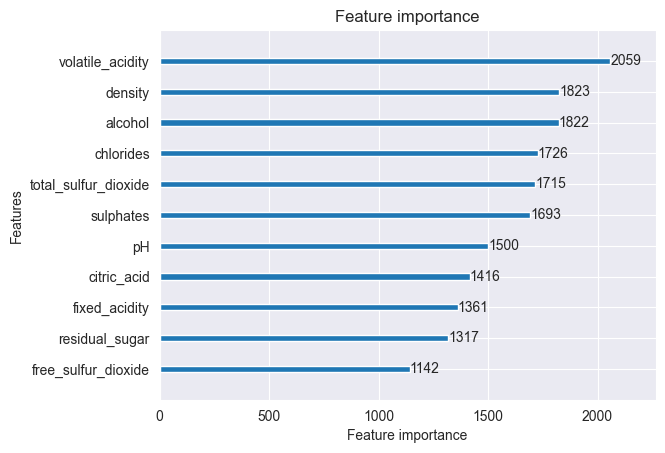

In [2]:
# pip install lightgbm
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 读取数据
df = pd.read_csv('./data/winequality-red.csv')
x = df.iloc[:, :-1]  # 特征,除了最后一列
y = df.iloc[:, -1]  # 标签,只有最后一列
y = y.map(lambda x: x - 3)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 参考y轴进行抽取,保持测试集和训练集的标签比例一致(数据均衡)
)
# 2. 构建模型
# 注意：LightGBM 对参数非常敏感，尤其是 num_leaves
model = LGBMClassifier(
    n_estimators=100,        # 树的数量
    learning_rate=0.1,       # 学习率
    num_leaves=31,           # 【关键参数】叶子节点数，LightGBM 不怎么看 max_depth，主要看这个
    max_depth=-1,            # -1 表示不限制深度 (Leaf-wise 的特性)
    random_state=42
)

# 3. 训练
model.fit(x_train, y_train)

# 4. 预测
y_pred = model.predict(x_test)

print(f"LightGBM 准确率: {accuracy_score(y_test, y_pred)}")

# 5. 它也有特征重要性
lgb.plot_importance(model)

### **CatBoost: CategoricalBoosting(类别提升)**

在之前所有的提升树中,遇到**非数值**特征列,通常都需要进行编码处理,比如ONE-HOT编码,
但是如果数据量很多,特征列类别也很多,特征维度就会爆炸式增长,数据变得稀疏,训练变慢.

**CatBoost** 的出现就是为了终结这个问题。 它可以直接接收字符串类型的特征，你不需要把它们转成数字，它会自动处理.

#### **Ordered Target Statistics（排序目标统计）**

简单来说，它的目的是：**把类别（如“北京”）变成数字，但是绝对不允许“作弊”！**

我们分三步来理解:
1. 为什么我们要把类别变成统计值？（背景）
2. 传统的做法哪里错了？（作弊/数据泄露）
3. CatBoost 是怎么聪明地解决这个问题的？（排序机制）

##### **第一步: 目标统计, 把类别变成统计值**